**Autor:** PEDRO HENRIQUE BENICIO DE OLIVEIRA — **RGM:** 33602697

# Entrega 1 — Análise Comparativa de Representações
**Ouvidoria Inteligente • NLP Aplicado**

Comparamos representações **esparsas** (BoW, TF-IDF) e **densas** (embeddings de sentenças) nas 40 manifestações,
avaliando a similaridade de cosseno em três pares-chave:

| Par | Relação esperada |
|---|---|
| M003 × M017 | mesmo problema (buraco/asfalto esburacado), palavras diferentes |
| M008 × M022 | mesmo problema (posto de saúde sem médico / PSF sem atendimento) |
| M008 × M031 | temas sem relação (saúde × iluminação) |

In [1]:
import os, warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import ouvidoria_utils as u

df = u.carregar_manifestacoes()
textos = df["texto"].tolist()
idx = {i: k for k, i in enumerate(df["id"])}   # id -> posição na matriz
print(f"{len(df)} manifestações | categorias: {df.categoria_oficial.value_counts().to_dict()}")
df.head()

40 manifestações | categorias: {'meio ambiente': 9, 'infraestrutura': 8, 'saúde': 8, 'educação': 8, 'segurança': 7}


,id,data,categoria_oficial,texto
0,M001,2025-03-03,infraestrutura,O poste de iluminação da Rua das Flores está a...
1,M002,2025-03-05,saúde,Fui à UPA com febre alta e esperei mais de cin...
2,M003,2025-03-06,infraestrutura,"Existe um buraco enorme na Av. Brasil, na altu..."
3,M004,2025-03-08,segurança,Assaltos frequentes na parada de ônibus da Rua...
4,M005,2025-03-10,educação,Escrevo para relatar a situação da escola muni...


## 1. Gerando as representações

In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

MODELOS = {
    "MiniLM-L12 (multilíngue)": "paraphrase-multilingual-MiniLM-L12-v2",
    "distiluse (multilíngue)": "sentence-transformers/distiluse-base-multilingual-cased-v2",
    "multilingual-e5-small": "intfloat/multilingual-e5-small",
}

X_bow = CountVectorizer().fit_transform(textos)
X_tfidf = TfidfVectorizer().fit_transform(textos)
print("BoW    :", X_bow.shape, f"| esparsidade {1 - X_bow.nnz / np.prod(X_bow.shape):.1%}")
print("TF-IDF :", X_tfidf.shape)

sims = {"BoW": cosine_similarity(X_bow), "TF-IDF": cosine_similarity(X_tfidf)}
for rotulo, nome in MODELOS.items():
    modelo = u.carregar_modelo(nome)
    emb = u.codificar(modelo, textos, nome)
    sims[rotulo] = cosine_similarity(emb)
    print(f"{rotulo:26s}: embeddings {emb.shape}")

BoW    : (40, 542) | esparsidade 95.1%
TF-IDF : (40, 542)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3032.37it/s]

MiniLM-L12 (multilíngue)  : embeddings (40, 384)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 948.00it/s]

distiluse (multilíngue)   : embeddings (40, 512)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2773.71it/s]

multilingual-e5-small     : embeddings (40, 384)


## 2. Similaridade de cosseno nos pares solicitados

In [3]:
pares = [("M003", "M017", "buraco Av. Brasil × asfalto esburacado"),
         ("M008", "M022", "posto sem médico × falta atendimento PSF"),
         ("M008", "M031", "posto sem médico × lâmpada queimada")]

tabela = pd.DataFrame(
    {rep: [S[idx[a], idx[b]] for a, b, _ in pares] for rep, S in sims.items()},
    index=[f"{a} × {b} — {desc}" for a, b, desc in pares])
tabela.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1)

,BoW,TF-IDF,MiniLM-L12 (multilíngue),distiluse (multilíngue),multilingual-e5-small
M003 × M017 — buraco Av. Brasil × asfalto esburacado,0.000,0.000,0.484,0.249,0.867
M008 × M022 — posto sem médico × falta atendimento PSF,0.163,0.074,0.797,0.560,0.897
M008 × M031 — posto sem médico × lâmpada queimada,0.000,0.000,0.099,0.141,0.894


In [4]:
# Textos dos pares, para conferência qualitativa
for a, b, _ in pares:
    print(f"{a}: {textos[idx[a]]}\n{b}: {textos[idx[b]]}\n")

M003: Existe um buraco enorme na Av. Brasil, na altura do número 1200, que já causou dois acidentes com motos. Precisa de reparo urgente.
M017: O asfalto da avenida principal está todo esburacado, os carros estão estragando pneus e suspensão.

M008: O posto de saúde do meu bairro está sem médico há mais de um mês e ninguém consegue marcar consulta.
M022: Falta atendimento no PSF da comunidade. Não tem doutor e os agentes de saúde não aparecem.

M008: O posto de saúde do meu bairro está sem médico há mais de um mês e ninguém consegue marcar consulta.
M031: A lâmpada queimada na praça deixa o local escuro à noite e afasta os moradores.



## 3. Escala dos scores: a similaridade média muda de modelo para modelo
Um mesmo valor de cosseno significa coisas diferentes em cada representação. Comparamos a distribuição
das similaridades entre **todos** os pares de manifestações distintas.

,mean,std,min,50%,max
BoW,0.166,0.105,0.000,0.158,0.572
TF-IDF,0.065,0.050,0.000,0.057,0.324
MiniLM-L12 (multilíngue),0.272,0.162,-0.095,0.254,0.890
distiluse (multilíngue),0.192,0.124,-0.040,0.172,0.811
multilingual-e5-small,0.870,0.020,0.812,0.872,0.926


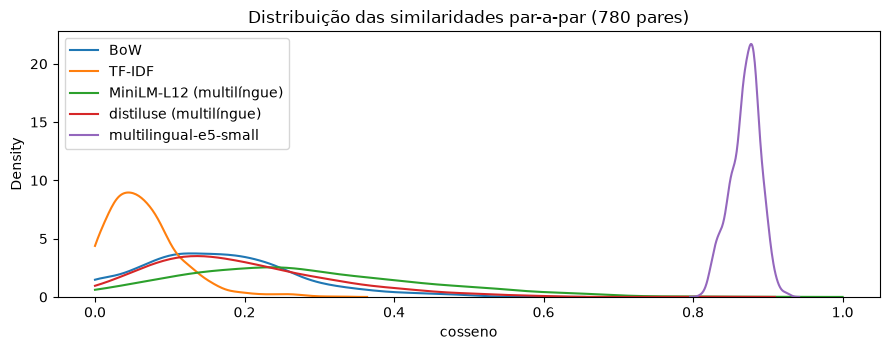

In [5]:
iu = np.triu_indices(len(df), k=1)
resumo = pd.DataFrame({rep: pd.Series(S[iu]).describe() for rep, S in sims.items()}).T[["mean", "std", "min", "50%", "max"]]
display(resumo.round(3))

fig, ax = plt.subplots(figsize=(9, 3.6))
for rep, S in sims.items():
    sns.kdeplot(S[iu], label=rep, ax=ax, clip=(0, 1))
ax.set(title="Distribuição das similaridades par-a-par (780 pares)", xlabel="cosseno")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Vocabulário compartilhado nos pares (por que BoW/TF-IDF falham?)

In [6]:
import re
def vocab(t):  # palavras (sem stopword curtas) do texto
    return {w for w in re.findall(r"\w+", t.lower()) if len(w) > 3}
for a, b, desc in pares:
    print(f"{a} × {b}: palavras em comum (>3 letras) = {sorted(vocab(textos[idx[a]]) & vocab(textos[idx[b]]))}")

M003 × M017: palavras em comum (>3 letras) = []
M008 × M022: palavras em comum (>3 letras) = ['saúde']
M008 × M031: palavras em comum (>3 letras) = []


## 5. Discussão e conclusão

**Resultados (execução de referência).**

| Par | BoW | TF-IDF | MiniLM-L12 | distiluse | e5-small |
|---|---|---|---|---|---|
| M003 × M017 (duplicata) | 0,00 | 0,00 | 0,48 | 0,25 | 0,87 |
| M008 × M022 (duplicata) | 0,16 | 0,07 | 0,80 | 0,56 | 0,90 |
| M008 × M031 (sem relação) | 0,00 | 0,00 | 0,10 | 0,14 | 0,89 |

* **BoW e TF-IDF** só enxergam sobreposição *literal* de palavras. M003 e M017 descrevem o mesmo problema sem
  compartilhar nenhuma palavra de conteúdo ("buraco" × "esburacado", "Av. Brasil" × "avenida principal"), por isso o
  cosseno é exatamente 0 — idêntico ao de um par sem qualquer relação (M008 × M031). No par M008 × M022 a única
  palavra em comum é "saúde" e o score fica baixíssimo (0,16 e 0,07). São vetores de ~540 dimensões com 95% de zeros:
  não capturam sinônimos, flexões, siglas (PSF = posto de saúde) nem contexto. O TF-IDF melhora a *ponderação*
  (reduz o peso de palavras comuns), mas não resolve o descasamento de vocabulário.
* **Embeddings densos** aproximam significados: o MiniLM dá 0,80 para posto sem médico × PSF sem atendimento e 0,10 para
  saúde × iluminação — separação clara. O par do buraco recebeu apenas 0,48: acima do não relacionado, mas abaixo do
  esperado, pois M003 traz detalhes específicos (número, acidentes com motos, urgência) que M017 não tem.
  O distiluse produz a mesma ordenação, com scores menores.
* **Cuidado com a escala.** O `multilingual-e5-small` dá 0,87–0,90 a *todos* os pares (média 0,87, desvio 0,02):
  o espaço é muito "anisotrópico" e o cosseno só discrimina com calibração própria — nele o par sem relação (0,89) ficou
  acima de uma duplicata (0,87). Um mesmo limiar (por exemplo 0,85) não é transferível entre modelos.

**Limitações.** *BoW/TF-IDF*: rápidos, interpretáveis e sem GPU, ótimos para termos exatos, mas cegos a sinônimos e
paráfrases. *Embeddings*: capturam semântica e paráfrases, porém são caixas-pretas, dependem do modelo e do domínio
(nenhum foi treinado em português jurídico/administrativo), têm scores não calibrados e podem confundir textos do
mesmo *tema* mas de *problemas diferentes* (ex.: duas reclamações de iluminação em locais distintos). Na prática,
uma abordagem híbrida (léxica + semântica) tende a ser a mais robusta.
